# IoT Intrusion Detection Workflow

This notebook follows the exact workflow:

1. Visualize raw data
2. Clean the data
3. Visualize cleaned data
4. Split into training and testing sets
5. Oversample the training set only


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_pipeline import (
    clean_dataset,
    describe_split,
    load_dataset,
    log_transform_features,
    oversample_training_set,
    split_dataset,
    summarize_dataset_labels,
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 1. Load and Visualize Raw Data

In [2]:
df_raw = load_dataset()

print("Raw shape:", df_raw.shape)
pd.Series(summarize_dataset_labels(df_raw))

Raw shape: (5838072, 48)


label_count                                                                34
labels                      [Backdoor_Malware, BenignTraffic, BrowserHijac...
labels_outside_schema       [Backdoor_Malware, CommandInjection, DDoS-ACK_...
labels_missing_from_data                                 [DDoS-TCP_SYN_Flood]
dtype: object

In [3]:
df_raw.head()

,flow_duration,header_length,protocol_type,duration,rate,srate,drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,ack_count,syn_count,fin_count,urg_count,rst_count,http,https,dns,telnet,smtp,ssh,irc,tcp,udp,dhcp,arp,icmp,igmp,ipv,llc,tot_sum,min,max,avg,std,tot_size,iat,number,magnitue,radius,covariance,variance,weight,label
0,0.5760,"17,006.4000",5.5000,60.6000,37.8194,37.8194,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.8000,0.0000,7.2000,20.7000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,"13,018.8000",66.0000,"2,922.0000",828.7658,843.9207,"1,068.8000","167,629,843.5838",13.5000,40.7507,"1,193.8145","713,244.4098",1.0000,244.6000,Backdoor_Malware
1,198.7577,"49,189.4000",7.1000,81.5000,49.8226,49.8226,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.8000,0.0000,7.2000,40.5000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,"9,205.0000",208.8000,"4,350.0000","1,454.7051","1,335.5266","1,938.8000",0.0083,5.5000,52.7562,"1,888.7198","2,471,854.4491",0.9000,38.5000,Backdoor_Malware
2,694.9429,"11,025.8000",9.8000,144.5000,0.5178,0.5178,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.4000,0.0000,2.0000,8.3000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,635.2000,60.0000,160.6000,99.1911,44.0256,143.6000,0.0818,5.5000,13.8851,62.2615,"3,122.5763",0.9000,38.5000,Backdoor_Malware
3,837.2362,"18,463.1000",8.2000,96.5000,10.1828,10.1828,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.7000,0.8000,0.0000,57.5000,95.3000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,553.4000,54.0000,177.2000,89.1236,51.0883,116.0000,0.0279,5.5000,13.2121,72.2498,"3,734.7784",0.7000,38.5000,Backdoor_Malware
4,788.4793,"39,576.5000",8.7000,97.9000,4.8519,4.8519,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000,169.3000,340.8000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,440.7000,50.0000,136.4000,77.0718,29.3169,76.6000,0.0504,5.5000,12.3714,41.4604,"1,051.3344",0.9000,38.5000,Backdoor_Malware


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5838072 entries, 0 to 5838071
Data columns (total 48 columns):
 #   Column           Dtype  
---  ------           -----  
 0   flow_duration    float64
 1   header_length    float64
 2   protocol_type    float64
 3   duration         float64
 4   rate             float64
 5   srate            float64
 6   drate            float64
 7   fin_flag_number  float64
 8   syn_flag_number  float64
 9   rst_flag_number  float64
 10  psh_flag_number  float64
 11  ack_flag_number  float64
 12  ece_flag_number  float64
 13  cwr_flag_number  float64
 14  ack_count        float64
 15  syn_count        float64
 16  fin_count        float64
 17  urg_count        float64
 18  rst_count        float64
 19  http             float64
 20  https            float64
 21  dns              float64
 22  telnet           float64
 23  smtp             float64
 24  ssh              float64
 25  irc              float64
 26  tcp              float64
 27  udp         

In [5]:
missing_raw = df_raw.isnull().sum()
missing_raw[missing_raw > 0]

Series([], dtype: int64)

In [6]:
df_raw.describe()

,flow_duration,header_length,protocol_type,duration,rate,srate,drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,ack_count,syn_count,fin_count,urg_count,rst_count,http,https,dns,telnet,smtp,ssh,irc,tcp,udp,dhcp,arp,icmp,igmp,ipv,llc,tot_sum,min,max,avg,std,tot_size,iat,number,magnitue,radius,covariance,variance,weight
count,"5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000","5,838,072.0000"
mean,35.7197,"268,819.4001",11.9894,72.1661,"7,335.5142","7,335.5142",0.0000,0.0490,0.1577,0.0604,0.0579,0.2052,0.0000,0.0000,0.0646,0.3785,0.0907,30.6035,149.5478,0.0508,0.1162,0.0005,0.0000,0.0000,0.0003,0.0000,0.5260,0.1845,0.0000,0.0004,0.0968,0.0000,0.9993,0.9993,"3,702.2445",188.9408,599.8294,352.9322,161.6622,352.9214,"83,254,792.9216",9.4964,21.8978,228.5069,"135,672.6129",0.3510,141.4586
std,748.0845,"899,721.4040",12.2021,26.3193,"86,322.8746","86,322.8746",0.0030,0.2159,0.3645,0.2383,0.2335,0.4039,0.0033,0.0023,0.2328,0.6975,0.4441,179.5372,661.0081,0.2196,0.3205,0.0231,0.0004,0.0007,0.0181,0.0011,0.4993,0.3879,0.0009,0.0204,0.2956,0.0000,0.0268,0.0268,"4,872.7393",237.5535,939.4521,443.5411,307.6111,444.3435,"36,324,597.9600",1.7445,14.6529,435.0844,"578,536.2434",0.4243,44.9031
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,42.0000,42.0000,42.0000,42.0000,0.0000,42.0000,0.0000,1.0000,9.1652,0.0000,0.0000,0.0000,1.0000
25%,0.0000,54.0000,6.0000,64.0000,2.9536,2.9536,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,567.0000,54.0000,54.0000,54.0000,0.0000,54.0000,"83,028,452.1855",9.5000,10.3923,0.0000,0.0000,0.0000,141.5500
50%,0.0382,108.0000,6.0000,64.0000,21.5132,21.5132,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,600.8750,54.0000,98.1000,66.5234,0.7291,66.0000,"83,284,275.9474",9.5000,11.4891,0.9717,3.2540,0.0900,141.5500
75%,2.2886,"31,284.0000",16.8300,65.7300,163.2787,163.2787,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.6000,0.0000,0.1200,0.9400,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,"6,069.0000",326.2400,687.6000,578.1817,168.5471,581.2800,"83,392,507.8749",9.5000,34.0000,236.8450,"52,108.2467",0.9000,141.5500
max,"186,698.3052","9,907,147.7500",47.0000,255.0000,"8,388,608.0000","8,388,608.0000",6.7995,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,7.4000,12.8700,248.3200,"4,312.5000","9,606.5000",1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,"127,335.8000","5,858.0000","49,014.0000","11,029.4595","12,385.2391","10,491.6000","167,639,436.0415",15.0000,143.4332,"17,551.2708","154,902,159.2477",1.0000,244.6000


In [7]:
label_counts_raw = df_raw["label"].value_counts()
label_counts_raw

label
DDoS-UDP_Fragmentation     285818
DoS-TCP_Flood              285742
DoS-SYN_Flood              285741
Mirai-greip_flood          285740
Mirai-greeth_flood         285739
DDoS-SYN_Flood             285739
DDoS-ICMP_Fragmentation    285738
DoS-UDP_Flood              285736
BenignTraffic              285733
DDoS-SynonymousIP_Flood    285731
DDoS-RSTFINFlood           285726
MITM-ArpSpoofing           285725
Mirai-udpplain             285724
DDoS-ICMP_Flood            285723
DDoS-UDP_Flood             285723
DDoS-TCP_Flood             285721
DDoS-PSHACK_Flood          285720
DDoS-ACK_Fragmentation     285104
DNS_Spoofing               178911
Recon-HostDiscovery        134378
Recon-OSScan                98259
Recon-PortScan              82284
DoS-HTTP_Flood              71864
VulnerabilityScan           37382
DDoS-HTTP_Flood             28790
DDoS-SlowLoris              23426
DictionaryBruteForce        13064
BrowserHijacking             5859
CommandInjection             5409
SqlInjec

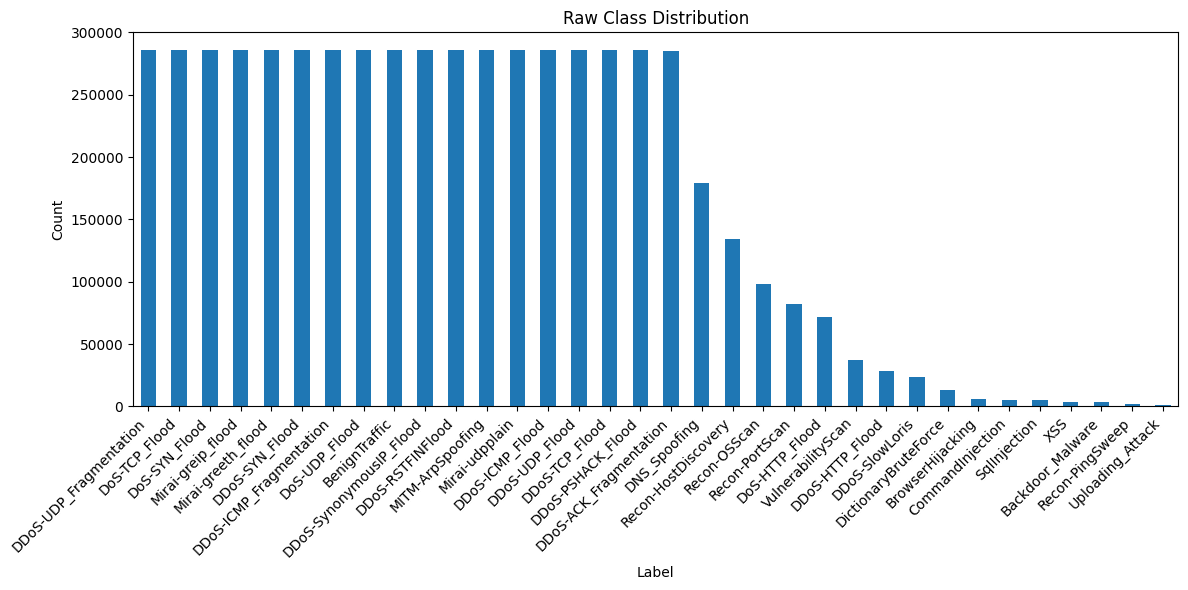

In [8]:
plt.figure(figsize=(12, 6))
label_counts_raw.plot(kind="bar")
plt.title("Raw Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [9]:
top_labels_raw = df_raw["label"].value_counts().head(5).index
df_raw_top = df_raw[df_raw["label"].isin(top_labels_raw)].copy()
df_raw_top["label"].value_counts()

label
DDoS-UDP_Fragmentation    285818
DoS-TCP_Flood             285742
DoS-SYN_Flood             285741
Mirai-greip_flood         285740
Mirai-greeth_flood        285739
Name: count, dtype: int64

<Figure size 1200x600 with 0 Axes>

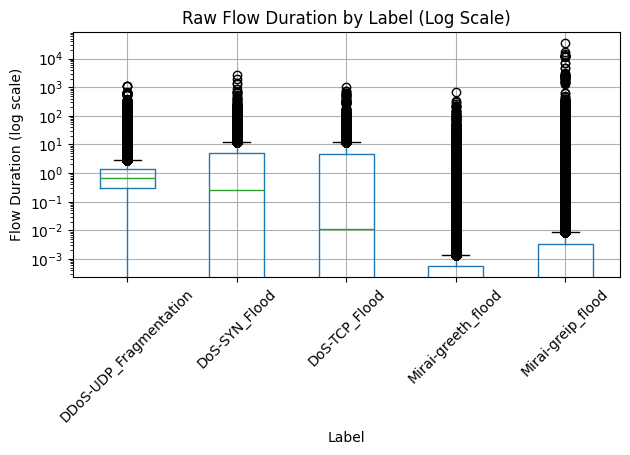

In [10]:
plt.figure(figsize=(12, 6))
df_raw_top.boxplot(column="flow_duration", by="label", rot=45)
plt.yscale("log")
plt.title("Raw Flow Duration by Label (Log Scale)")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("Flow Duration (log scale)")
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

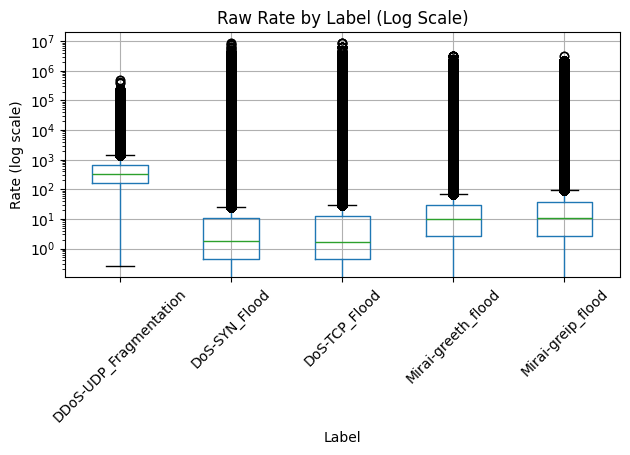

In [11]:
plt.figure(figsize=(12, 6))
df_raw_top.boxplot(column="rate", by="label", rot=45)
plt.yscale("log")
plt.title("Raw Rate by Label (Log Scale)")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("Rate (log scale)")
plt.tight_layout()
plt.show()

## 2. Cleaning Configuration

Set `selected_labels = None` to keep all labels, or replace it with a list if you want to work on a subset.

In [12]:
selected_labels = None

# Example subset:
# selected_labels = [
#     "BenignTraffic",
#     "DDoS-UDP_Fragmentation",
#     "DoS-TCP_Flood",
#     "DoS-SYN_Flood",
#     "Mirai-greip_flood",
# ]

apply_log_transform = True

## 3. Clean the Data

In [13]:
df_clean = clean_dataset(df_raw, allowed_labels=selected_labels)

if apply_log_transform:
    df_clean = log_transform_features(df_clean, columns=["flow_duration", "rate"])

print("Clean shape:", df_clean.shape)
print("Rows removed during cleaning:", len(df_raw) - len(df_clean))
pd.Series(summarize_dataset_labels(df_clean))

Clean shape: (5838066, 48)
Rows removed during cleaning: 6


label_count                                                                34
labels                      [Backdoor_Malware, BenignTraffic, BrowserHijac...
labels_outside_schema       [Backdoor_Malware, CommandInjection, DDoS-ACK_...
labels_missing_from_data                                 [DDoS-TCP_SYN_Flood]
dtype: object

## 4. Visualize Cleaned Data

In [14]:
df_clean.head()

,flow_duration,header_length,protocol_type,duration,rate,srate,drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,ack_count,syn_count,fin_count,urg_count,rst_count,http,https,dns,telnet,smtp,ssh,irc,tcp,udp,dhcp,arp,icmp,igmp,ipv,llc,tot_sum,min,max,avg,std,tot_size,iat,number,magnitue,radius,covariance,variance,weight,label
0,0.4549,"17,006.4000",5.5000,60.6000,3.6589,37.8194,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.8000,0.0000,7.2000,20.7000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,"13,018.8000",66.0000,"2,922.0000",828.7658,843.9207,"1,068.8000","167,629,843.5838",13.5000,40.7507,"1,193.8145","713,244.4098",1.0000,244.6000,Backdoor_Malware
1,5.2971,"49,189.4000",7.1000,81.5000,3.9283,49.8226,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.8000,0.0000,7.2000,40.5000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,"9,205.0000",208.8000,"4,350.0000","1,454.7051","1,335.5266","1,938.8000",0.0083,5.5000,52.7562,"1,888.7198","2,471,854.4491",0.9000,38.5000,Backdoor_Malware
2,6.5453,"11,025.8000",9.8000,144.5000,0.4173,0.5178,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.4000,0.0000,2.0000,8.3000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,635.2000,60.0000,160.6000,99.1911,44.0256,143.6000,0.0818,5.5000,13.8851,62.2615,"3,122.5763",0.9000,38.5000,Backdoor_Malware
3,6.7313,"18,463.1000",8.2000,96.5000,2.4144,10.1828,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.7000,0.8000,0.0000,57.5000,95.3000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,553.4000,54.0000,177.2000,89.1236,51.0883,116.0000,0.0279,5.5000,13.2121,72.2498,"3,734.7784",0.7000,38.5000,Backdoor_Malware
4,6.6714,"39,576.5000",8.7000,97.9000,1.7668,4.8519,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000,169.3000,340.8000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,440.7000,50.0000,136.4000,77.0718,29.3169,76.6000,0.0504,5.5000,12.3714,41.4604,"1,051.3344",0.9000,38.5000,Backdoor_Malware


In [15]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5838066 entries, 0 to 5838065
Data columns (total 48 columns):
 #   Column           Dtype  
---  ------           -----  
 0   flow_duration    float64
 1   header_length    float64
 2   protocol_type    float64
 3   duration         float64
 4   rate             float64
 5   srate            float64
 6   drate            float64
 7   fin_flag_number  float64
 8   syn_flag_number  float64
 9   rst_flag_number  float64
 10  psh_flag_number  float64
 11  ack_flag_number  float64
 12  ece_flag_number  float64
 13  cwr_flag_number  float64
 14  ack_count        float64
 15  syn_count        float64
 16  fin_count        float64
 17  urg_count        float64
 18  rst_count        float64
 19  http             float64
 20  https            float64
 21  dns              float64
 22  telnet           float64
 23  smtp             float64
 24  ssh              float64
 25  irc              float64
 26  tcp              float64
 27  udp         

In [16]:
missing_clean = df_clean.isnull().sum()
missing_clean[missing_clean > 0]

Series([], dtype: int64)

In [17]:
df_clean.describe()

,flow_duration,header_length,protocol_type,duration,rate,srate,drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,ack_count,syn_count,fin_count,urg_count,rst_count,http,https,dns,telnet,smtp,ssh,irc,tcp,udp,dhcp,arp,icmp,igmp,ipv,llc,tot_sum,min,max,avg,std,tot_size,iat,number,magnitue,radius,covariance,variance,weight
count,"5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000","5,838,066.0000"
mean,0.8299,"268,819.6764",11.9894,72.1661,3.6842,"7,335.5169",0.0000,0.0490,0.1577,0.0604,0.0579,0.2052,0.0000,0.0000,0.0646,0.3785,0.0907,30.6036,149.5480,0.0508,0.1162,0.0005,0.0000,0.0000,0.0003,0.0000,0.5260,0.1845,0.0000,0.0004,0.0968,0.0000,0.9993,0.9993,"3,702.2479",188.9410,599.8299,352.9325,161.6624,352.9217,"83,254,878.4857",9.4964,21.8978,228.5071,"135,672.7523",0.3510,141.4587
std,1.4523,"899,721.8251",12.2021,26.3193,2.8404,"86,322.9183",0.0030,0.2159,0.3645,0.2383,0.2335,0.4039,0.0033,0.0023,0.2328,0.6975,0.4441,179.5373,661.0084,0.2196,0.3205,0.0231,0.0004,0.0007,0.0181,0.0011,0.4993,0.3879,0.0009,0.0204,0.2956,0.0000,0.0268,0.0268,"4,872.7406",237.5536,939.4524,443.5412,307.6112,444.3436,"36,324,518.5708",1.7445,14.6529,435.0845,"578,536.5243",0.4243,44.9030
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,42.0000,42.0000,42.0000,42.0000,0.0000,42.0000,0.0000,1.0000,9.1652,0.0000,0.0000,0.0000,1.0000
25%,0.0000,54.0000,6.0000,64.0000,1.3746,2.9536,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,567.0000,54.0000,54.0000,54.0000,0.0000,54.0000,"83,028,452.2008",9.5000,10.3923,0.0000,0.0000,0.0000,141.5500
50%,0.0375,108.0000,6.0000,64.0000,3.1141,21.5132,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,600.8800,54.0000,98.1050,66.5237,0.7291,66.0000,"83,284,275.9573",9.5000,11.4891,0.9717,3.2540,0.0900,141.5500
75%,1.1905,"31,284.0000",16.8300,65.7300,5.1016,163.2787,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.6000,0.0000,0.1200,0.9400,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,"6,069.0000",326.2400,687.6000,578.1817,168.5500,581.2800,"83,392,507.8805",9.5000,34.0000,236.8479,"52,109.1854",0.9000,141.5500
max,12.1373,"9,907,147.7500",47.0000,255.0000,15.9424,"8,388,608.0000",6.7995,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,7.4000,12.8700,248.3200,"4,312.5000","9,606.5000",1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,"127,335.8000","5,858.0000","49,014.0000","11,029.4595","12,385.2391","10,491.6000","167,639,436.0415",15.0000,143.4332,"17,551.2708","154,902,159.2477",1.0000,244.6000


In [18]:
label_counts_clean = df_clean["label"].value_counts()
label_counts_clean

label
DDoS-UDP_Fragmentation     285818
DoS-TCP_Flood              285742
DoS-SYN_Flood              285741
Mirai-greip_flood          285740
Mirai-greeth_flood         285739
DDoS-SYN_Flood             285739
DDoS-ICMP_Fragmentation    285738
DoS-UDP_Flood              285736
BenignTraffic              285733
DDoS-SynonymousIP_Flood    285731
DDoS-RSTFINFlood           285726
MITM-ArpSpoofing           285725
Mirai-udpplain             285724
DDoS-ICMP_Flood            285723
DDoS-UDP_Flood             285723
DDoS-TCP_Flood             285721
DDoS-PSHACK_Flood          285720
DDoS-ACK_Fragmentation     285104
DNS_Spoofing               178910
Recon-HostDiscovery        134377
Recon-OSScan                98259
Recon-PortScan              82280
DoS-HTTP_Flood              71864
VulnerabilityScan           37382
DDoS-HTTP_Flood             28790
DDoS-SlowLoris              23426
DictionaryBruteForce        13064
BrowserHijacking             5859
CommandInjection             5409
SqlInjec

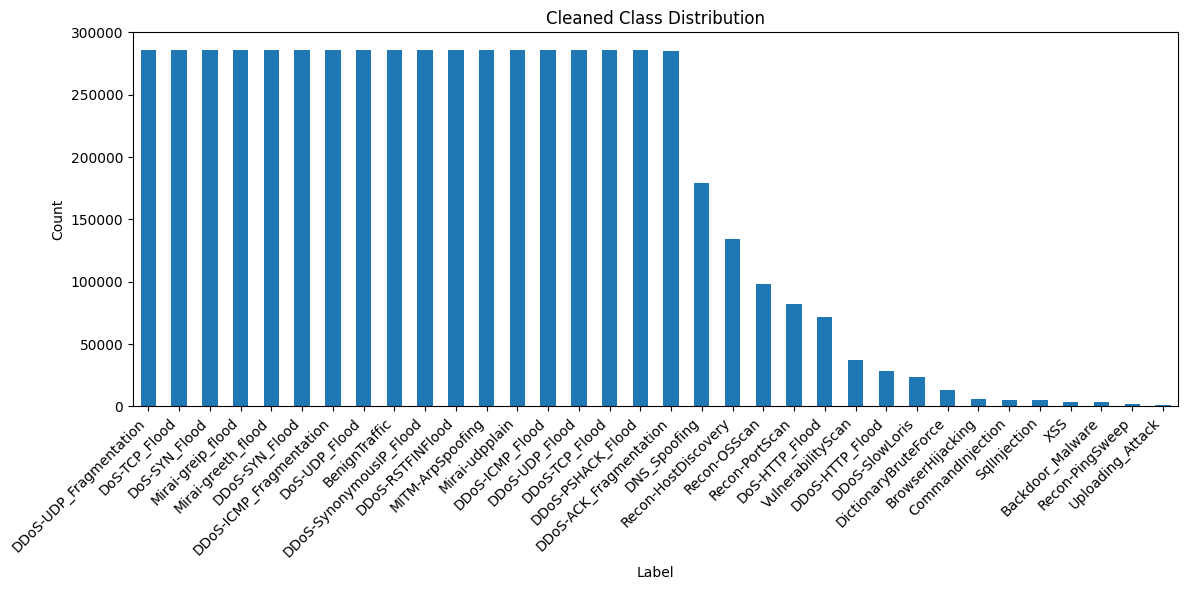

In [19]:
plt.figure(figsize=(12, 6))
label_counts_clean.plot(kind="bar")
plt.title("Cleaned Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [20]:
top_labels_clean = df_clean["label"].value_counts().head(5).index
df_clean_top = df_clean[df_clean["label"].isin(top_labels_clean)].copy()
df_clean_top["label"].value_counts()

label
DDoS-UDP_Fragmentation    285818
DoS-TCP_Flood             285742
DoS-SYN_Flood             285741
Mirai-greip_flood         285740
Mirai-greeth_flood        285739
Name: count, dtype: int64

<Figure size 1200x600 with 0 Axes>

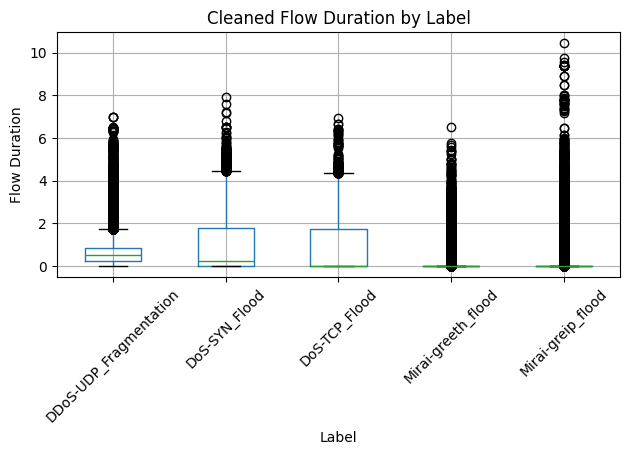

In [21]:
plt.figure(figsize=(12, 6))
df_clean_top.boxplot(column="flow_duration", by="label", rot=45)
plt.title("Cleaned Flow Duration by Label")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("Flow Duration")
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

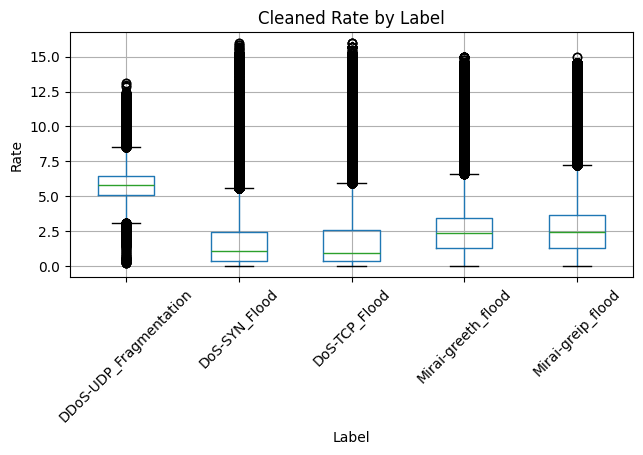

In [22]:
plt.figure(figsize=(12, 6))
df_clean_top.boxplot(column="rate", by="label", rot=45)
plt.title("Cleaned Rate by Label")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("Rate")
plt.tight_layout()
plt.show()

In [23]:
comparison_summary = pd.DataFrame(
    {
        "raw_rows": [len(df_raw)],
        "clean_rows": [len(df_clean)],
        "rows_removed": [len(df_raw) - len(df_clean)],
        "raw_label_count": [df_raw["label"].nunique()],
        "clean_label_count": [df_clean["label"].nunique()],
    }
)
comparison_summary

,raw_rows,clean_rows,rows_removed,raw_label_count,clean_label_count
0,5838072,5838066,6,34,34


## 5. Split the Cleaned Data

In [24]:
splits = split_dataset(df_clean, test_size=0.2, random_state=42)

print("X_train shape:", splits.X_train.shape)
print("X_test shape:", splits.X_test.shape)
print("y_train shape:", splits.y_train.shape)
print("y_test shape:", splits.y_test.shape)

X_train shape: (4670452, 47)
X_test shape: (1167614, 47)
y_train shape: (4670452,)
y_test shape: (1167614,)


In [25]:
split_distribution = describe_split(splits.y_train, splits.y_test)
split_distribution

,train,test
label,,
Backdoor_Malware,2574,644
BenignTraffic,228586,57147
BrowserHijacking,4687,1172
CommandInjection,4327,1082
DDoS-ACK_Fragmentation,228083,57021
DDoS-HTTP_Flood,23032,5758
DDoS-ICMP_Flood,228578,57145
DDoS-ICMP_Fragmentation,228590,57148
DDoS-PSHACK_Flood,228576,57144


## 6. Oversample the Training Set Only

In [26]:
X_train_balanced, y_train_balanced = oversample_training_set(
    splits.X_train,
    splits.y_train,
    random_state=42,
)

print("Balanced X_train shape:", X_train_balanced.shape)
print("Balanced y_train shape:", y_train_balanced.shape)

Balanced X_train shape: (7774236, 47)
Balanced y_train shape: (7774236,)


In [27]:
oversampling_comparison = pd.concat(
    [
        splits.y_train.value_counts().rename("train_before_oversampling"),
        y_train_balanced.value_counts().rename("train_after_oversampling"),
        splits.y_test.value_counts().rename("test_unchanged"),
    ],
    axis=1,
).fillna(0).astype(int).sort_index()

oversampling_comparison

,train_before_oversampling,train_after_oversampling,test_unchanged
label,,,
Backdoor_Malware,2574,228654,644
BenignTraffic,228586,228654,57147
BrowserHijacking,4687,228654,1172
CommandInjection,4327,228654,1082
DDoS-ACK_Fragmentation,228083,228654,57021
DDoS-HTTP_Flood,23032,228654,5758
DDoS-ICMP_Flood,228578,228654,57145
DDoS-ICMP_Fragmentation,228590,228654,57148
DDoS-PSHACK_Flood,228576,228654,57144


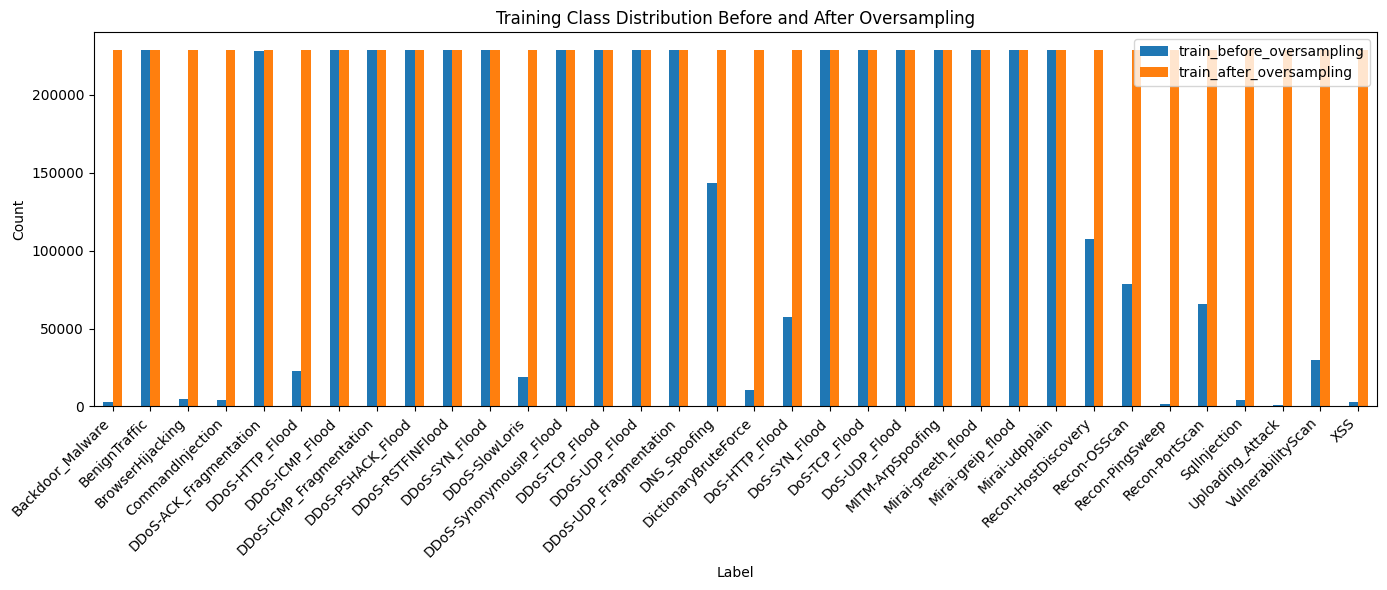

In [28]:
oversampling_comparison[["train_before_oversampling", "train_after_oversampling"]].plot(
    kind="bar",
    figsize=(14, 6),
)
plt.title("Training Class Distribution Before and After Oversampling")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

This final section should show that:

- the split happens after cleaning
- only the training set is oversampled
- the test set keeps the original class distribution
- rare attacks are preserved rather than removed